In [1]:
#Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [2]:
#Loding the dataset

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

train_df.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [3]:
train_df.shape

(140700, 20)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [5]:
train_df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [6]:
train_df.isnull().sum()

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [7]:
#target balance

train_df["Depression"].value_counts()

Depression
0    115133
1     25567
Name: count, dtype: int64

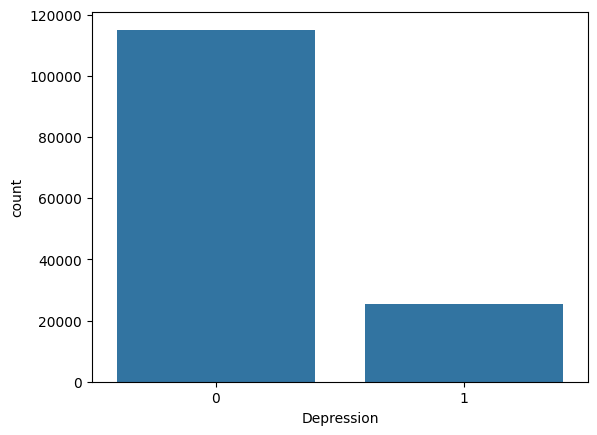

In [8]:
#target balance visualization

sns.countplot(x="Depression", data=train_df)
plt.show()

In [9]:
#Drop unnecessary columns

train_df.drop(columns=["id", "Name"], inplace=True)
test_df.drop(columns=["id", "Name"], inplace=True)

In [ ]:
#Handle Missing Values- Numerical columns: Fill with median

num_cols_train = train_df.select_dtypes(include=np.number).columns.drop("Depression")
for col in num_cols_train:
    train_df[col].fillna(train_df[col].median(), inplace=True)

num_cols_test = test_df.select_dtypes(include=np.number).columns
for col in num_cols_test:
    test_df[col].fillna(test_df[col].median(), inplace=True)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7840\430280438.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7840\430280438.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [13]:
#Handle Missing Values- Categorical columns: Fill with mode

cat_cols = train_df.select_dtypes(include="object").columns

for col in cat_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    test_df[col].fillna(test_df[col].mode()[0], inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7840\1185496591.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mode()[0], inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7840\1185496591.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [15]:
#Encoding Categorical columns using Label Encoding

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    all_values = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(all_values)

    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

    label_encoders[col] = le

In [16]:
#Split Features & Target

X = train_df.drop("Depression", axis=1)
y = train_df["Depression"]

In [17]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Feature Scaling using StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
import torch
print(torch.__version__)

2.8.0+cpu


In [ ]:
#Convert Features to Tensors

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [ ]:
#Convert Target to Tensors

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [23]:
#Building the Neural Network Model

import torch.nn as nn

class DepressionModel(nn.Module):
    
    def __init__(self, input_size):
        
        super(DepressionModel, self).__init__()
        
        self.network = nn.Sequential(
            
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.network(x)

In [25]:
#initialize the model
input_size = X_train.shape[1]

model = DepressionModel(input_size)

In [26]:
#loss function and optimizer

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [28]:
#training loops

epochs = 50

for epoch in range(epochs):
    
    # Forward Pass
    outputs = model(X_train_tensor).squeeze()
    
    loss = criterion(outputs, y_train_tensor)
    
    # Backward Pass
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [5/50], Loss: 0.6029
Epoch [10/50], Loss: 0.5278
Epoch [15/50], Loss: 0.4661
Epoch [20/50], Loss: 0.4130
Epoch [25/50], Loss: 0.3637
Epoch [30/50], Loss: 0.3187
Epoch [35/50], Loss: 0.2808
Epoch [40/50], Loss: 0.2509
Epoch [45/50], Loss: 0.2282
Epoch [50/50], Loss: 0.2121


In [29]:
#model predictions

with torch.no_grad():
    
    y_pred = model(X_test_tensor).squeeze()

In [30]:
#Convert probabilities to binary predictions

y_pred_classes = (y_pred >= 0.5).int()

In [33]:
#evaluation metrics

accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9219616204690831
Precision: 0.8262020291133657
Recall   : 0.726814124951494
F1 Score : 0.773327828241123


In [34]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     22986
           1       0.83      0.73      0.77      5154

    accuracy                           0.92     28140
   macro avg       0.88      0.85      0.86     28140
weighted avg       0.92      0.92      0.92     28140



In [35]:
torch.save(model.state_dict(), "../artifacts/model.pth")

In [37]:
import pickle

with open("../artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../artifacts/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)